# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [2]:
df.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [6]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

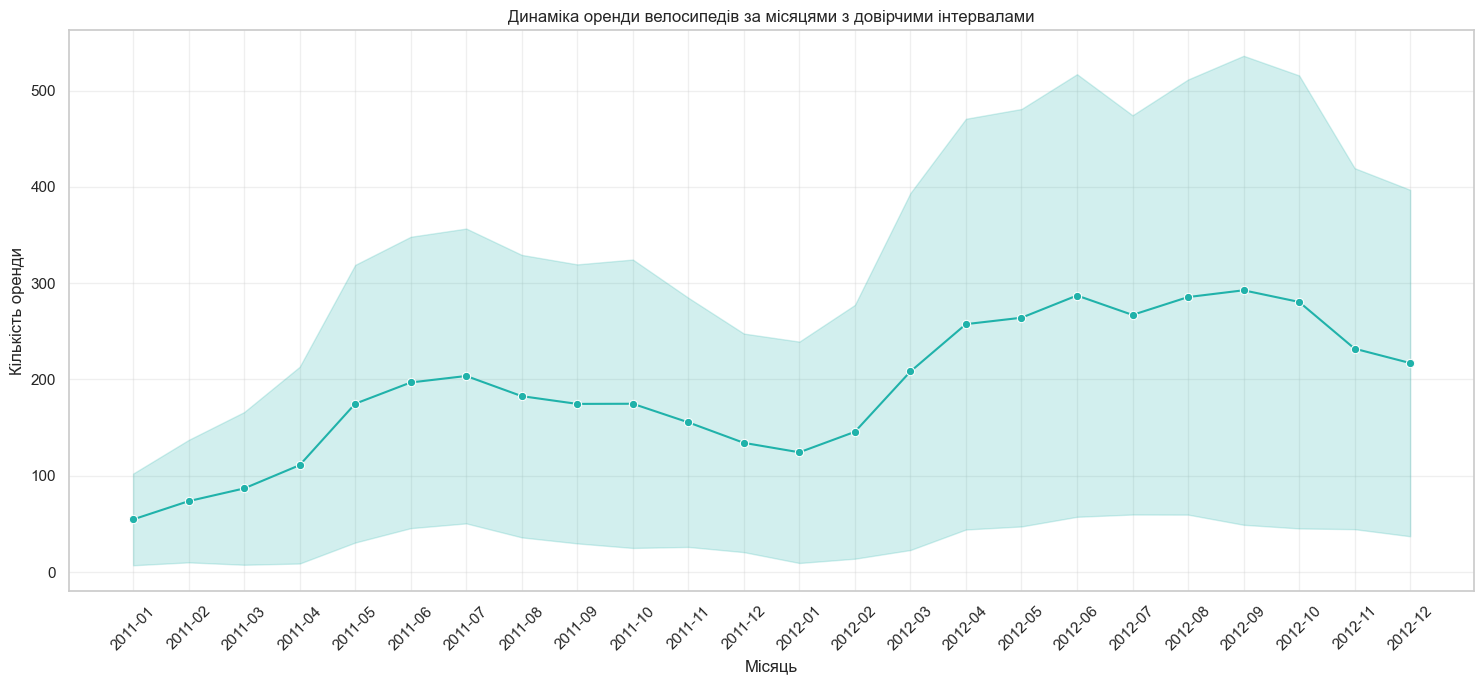

In [10]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='month_year', y='count', errorbar='sd', marker='o', color='#20B2AA')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**В які місяці найбільша невизначеність в даних?**

Найбільша невизначеність спостерігається у літній та осінній періоди (червень – вересень).
У ці місяці середня кількість оренд найвища, але й стандартне відхилення високе. 

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

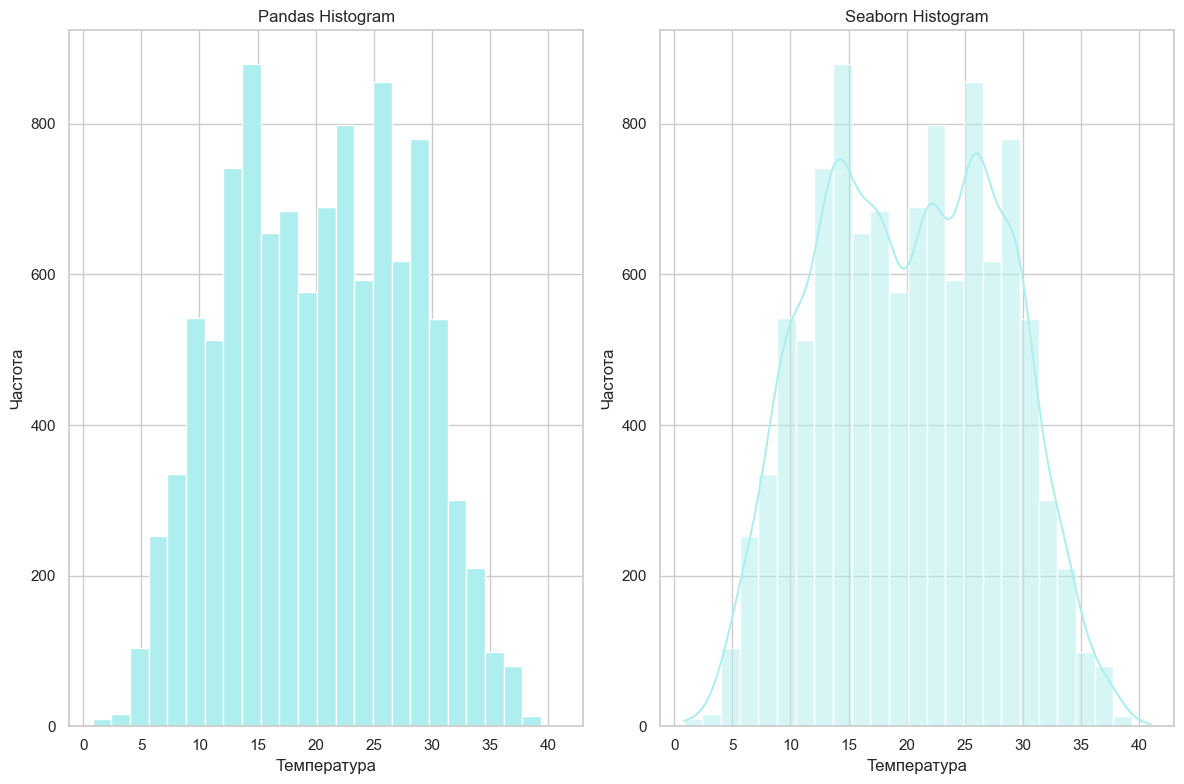

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

df['temp'].plot(kind='hist', bins=25, ax=ax[0], color='#AFEEEE')
ax[0].set_title('Pandas Histogram')
ax[0].set_xlabel('Температура')
ax[0].set_ylabel('Частота')

# 2. Seaborn Histogram
sns.histplot(df['temp'], bins=25, kde=True, ax=ax[1], color='#AFEEEE')
ax[1].set_title('Seaborn Histogram')
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

**Яка візуальна різниця між Pandas та Seaborn гістограмами?**

Pandas малює дуже базовий графік, часто без підписів осей, якщо їх не додати вручну. Seaborn автоматично додає підписи осей, має більш м'які кольори, має прозорість яка дозволяє бачити сітку.

**Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?**

Це згладжена версія гістограми. Вона дозволяє побачити загальну форму розподілу (чи він симетричний, чи має кілька піків), не відволікаючись на розриви між стовпчиками.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

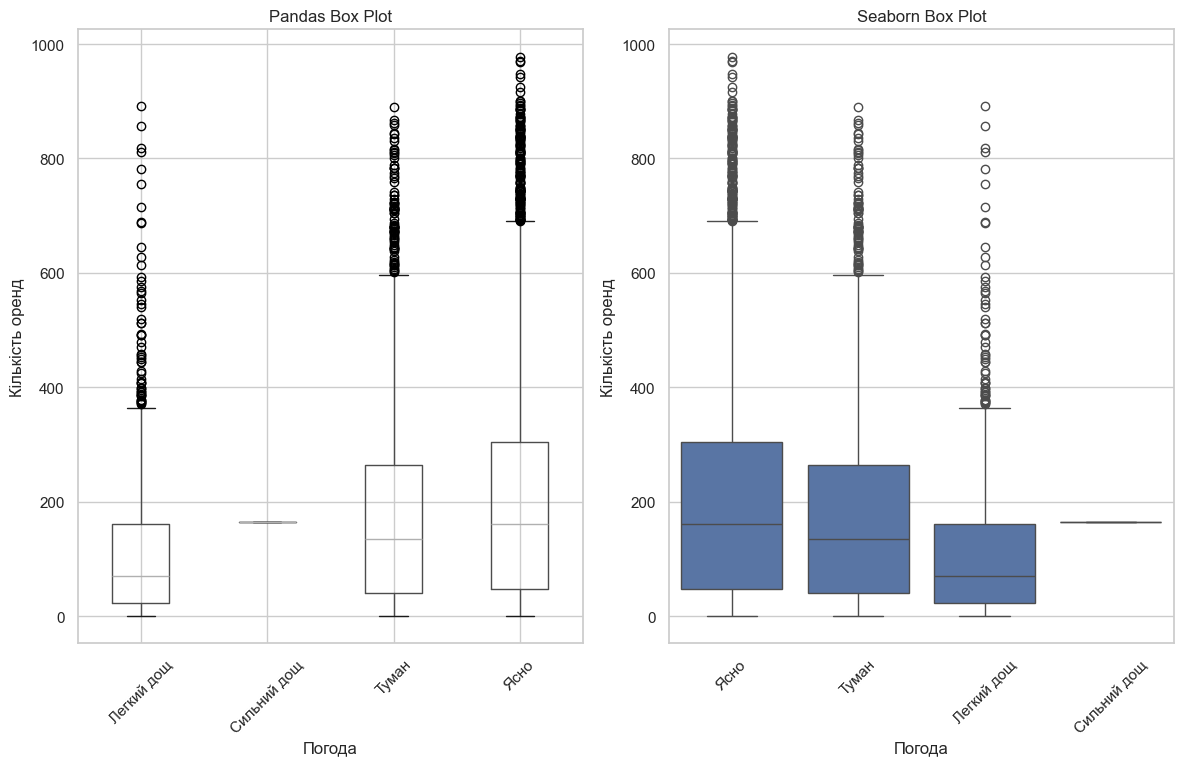

In [25]:
weather_labels = {
    1: 'Ясно', 
    2: 'Туман', 
    3: 'Легкий дощ', 
    4: 'Сильний дощ'
}
df['weather_desc'] = df['weather'].map(weather_labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 8))

df.boxplot(column='count', by='weather_desc', ax=ax[0])
ax[0].set_title('Pandas Box Plot')
ax[0].set_xlabel('Погода')
ax[0].set_ylabel('Кількість оренд')
ax[0].tick_params(axis='x', rotation=45)
plt.suptitle('') 

sns.boxplot(data=df, x='weather_desc', y='count', ax=ax[1])
ax[1].set_title('Seaborn Box Plot')
ax[1].set_xlabel('Погода')
ax[1].set_ylabel('Кількість оренд')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Яка візуальна різниця між Pandas та Seaborn бокс-плотами?**

Pandas малює графіки чорно-білі, а Seaborn автоматично застосовує кольорові палітри, що робить графік візуально привабливішим та легшим для сприйняття.
В Pandas для створення Box Plot за категоріями потрібно використовувати параметр by, що автоматично додає додаткові технічні заголовки, Seaborn обробляє групування набагато елегантніше через параметри x та y.


<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


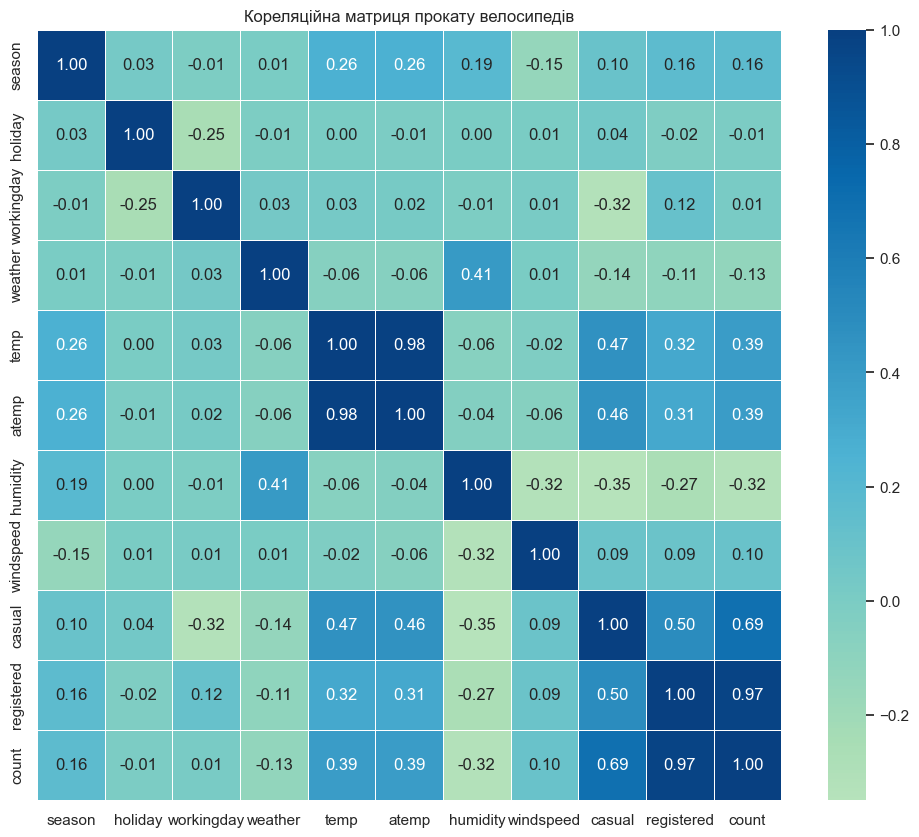

In [34]:
correlation = df[['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation, 
    annot=True,
    fmt=".2f",
    cmap='GnBu',
    center=0,
    linewidths=0.5
)
plt.title('Кореляційна матриця прокату велосипедів')
plt.show()

**Які змінні найсильніше корелюють з загальною кількістю оренди (count)?**
Найвищі показники кореляції мають:

`registered` (0.97): Вона вказує на те, що загальна кількість оренд майже повністю визначається активністю зареєстрованих користувачів.

`casual` (0.69): Також сильна позитивна кореляція, що свідчить про значний внесок випадкових орендарів у загальний обсяг.

`temp` та `atemp` (0.39): Температура має помірний позитивний вплив; чим тепліше на вулиці, тим більше людей користуються велосипедами.

**Яка кореляція між temp та atemp? Чому?**

Кореляція між фактичною (temp) та відчутною (atemp) температурою становить `0.98` адже "відчутна" температура в більшості випадків співпадала з фактичою. 

**Які змінні мають негативну кореляцію?**

humidity та count (-0.32)

weather та count (-0.13)

holiday та workingday (-0.25)

humidity та windspeed (-0.32)



## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


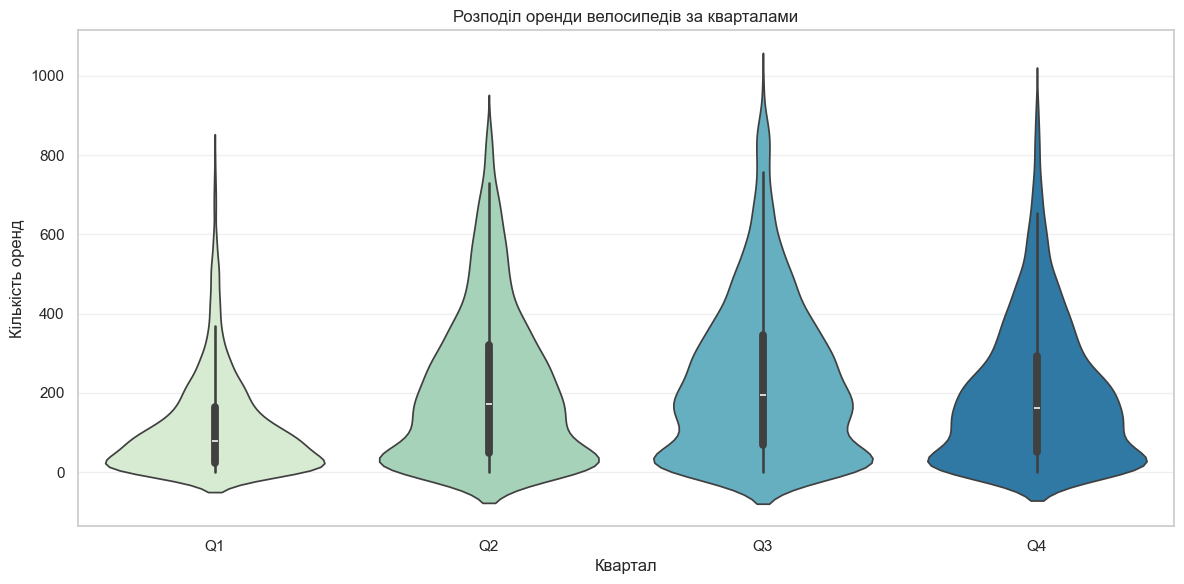

In [41]:
quarter_labels = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['quarter'] = df['season'].map(quarter_labels)

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='quarter', y='count', hue='quarter', palette='GnBu', legend=False)
plt.title('Розподіл оренди велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Що показує "товщина" violin plot?**

Товщина показує щільність розподілу (частоту) значень у цьому діапазоні. Чим ширша частина "скрипки", тим більше спостережень мають саме таку кількість оренд.

**В якому кварталі найбільша варіабельність оренди?**

Варіабельність найбільша в 3-му кварталі (Q3). Це видно за тим, наскільки сильно витягнута "скрипка" по вертикалі та наскільки широким є діапазон між мінімальними та максимальними значеннями.

**Яка перевага violin plot над звичайним box plot?**

Box plot показує лише основні точки (мінімум, медіану, максимуми), але він "плаский". Violin plot же дозволяє побачити форму розподілу.


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

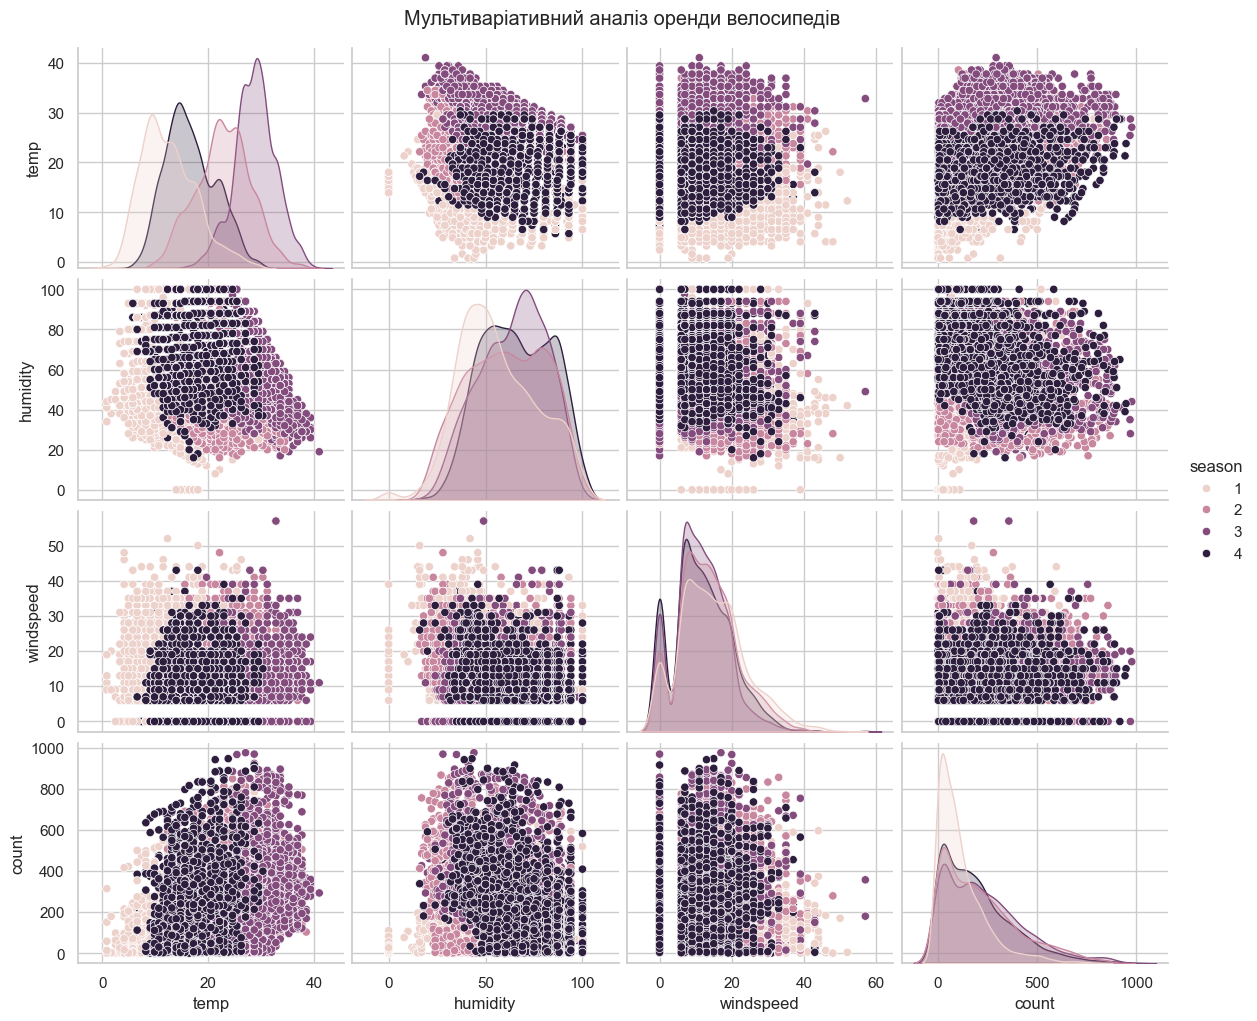

In [53]:
columns_to_plot = ['temp', 'humidity', 'windspeed', 'count', 'season']

sns.pairplot(df[columns_to_plot], hue='season', height=2.5, aspect=1.2)
plt.suptitle('Мультиваріативний аналіз оренди велосипедів', y=1.02)
plt.show()

**Між якими змінними спостерігається найсильніший лінійний зв'язок?**

Найсильніший лінійний зв'язок спостерігається між temp (температурою) та count (кількістю оренд). На відповідному графіку розсіювання (scatter plot) чітко видно висхідну тенденцію: чим вища температура, тим густіше і вище розташовані точки кількості оренд.

**Яка характеристика найбільше відрізняється між кварталами?**

Найбільше між кварталами відрізняється temp (температура). Це найкраще видно на діагональних графіках щільності. Розподіли температури для різних сезонів майже не перекриваються. Також суттєво відрізняється count, оскільки в холодні сезони (1-й квартал) пік розподілу зміщений до низьких значень, а в теплі — до високих.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

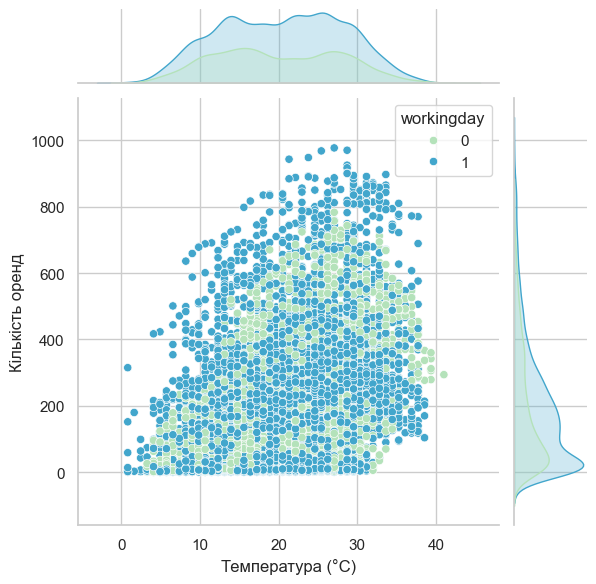

In [60]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday", palette='GnBu');
plt.xlabel('Температура (°C)')
plt.ylabel( 'Кількість оренд')
plt.show()

**Що показують графіки по краях?**
Графіки по краях показують одновимірний розподіл кожної змінної окремо.

Верхній графік показує розподіл температури, правий графік показує розподіл кількості оренд.

**Чи є різниця у поведінці користувачів у робочий і неробочий день?**

В обох випадках кількість оренд зростає із підвищенням температури. Сині точки відповідають за робочий день, зелені - вихідний. Синіх точок значно більше що дає підстави вважати що більша кількість оренд припадає на будні дні, тобто люди орендують велосипеди переважно для роботи. 
